In [64]:
import warnings 
warnings.filterwarnings("ignore")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np 

df = pd.read_csv('abalone.data')

In [65]:
# Add column names manually (from abalone.names file)
df.columns = [
    "Sex", "Length", "Diameter", "Height",
    "WholeWeight", "ShuckedWeight", "VisceraWeight",
    "ShellWeight", "Rings"
]

In [66]:
# print(df.head())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4176 entries, 0 to 4175
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sex            4176 non-null   object 
 1   Length         4176 non-null   float64
 2   Diameter       4176 non-null   float64
 3   Height         4176 non-null   float64
 4   WholeWeight    4176 non-null   float64
 5   ShuckedWeight  4176 non-null   float64
 6   VisceraWeight  4176 non-null   float64
 7   ShellWeight    4176 non-null   float64
 8   Rings          4176 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [67]:
df

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
1,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
2,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.1200,8
...,...,...,...,...,...,...,...,...,...
4171,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4172,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4173,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4174,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [68]:
print(df.head())

  Sex  Length  Diameter  Height  WholeWeight  ShuckedWeight  VisceraWeight  \
0   M   0.350     0.265   0.090       0.2255         0.0995         0.0485   
1   F   0.530     0.420   0.135       0.6770         0.2565         0.1415   
2   M   0.440     0.365   0.125       0.5160         0.2155         0.1140   
3   I   0.330     0.255   0.080       0.2050         0.0895         0.0395   
4   I   0.425     0.300   0.095       0.3515         0.1410         0.0775   

   ShellWeight  Rings  
0        0.070      7  
1        0.210      9  
2        0.155     10  
3        0.055      7  
4        0.120      8  


<Axes: >

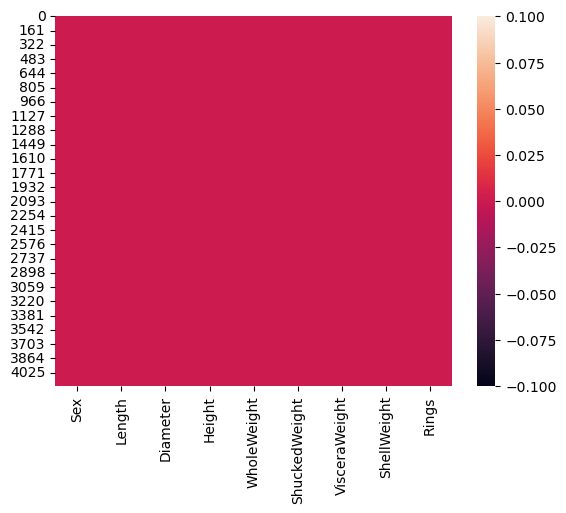

In [69]:
sns.heatmap(df.isnull())

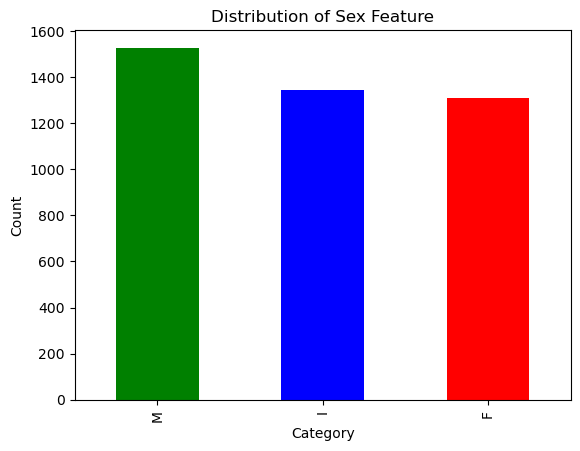

In [70]:
df["Sex"].value_counts().plot(kind = 'bar',color = ['green','blue','red'])
plt.title("Distribution of Sex Feature")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

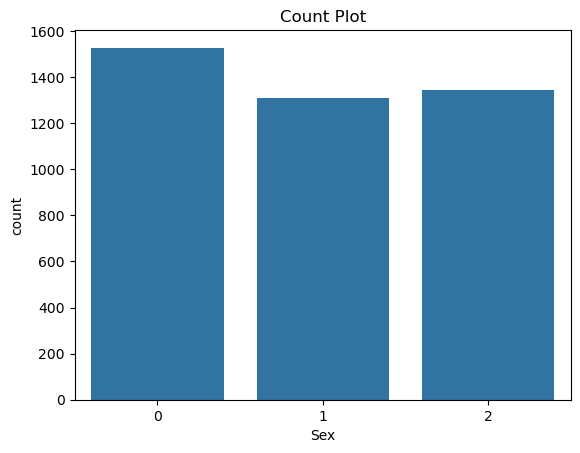

In [71]:
df['Sex']= df["Sex"].map({"M":0,"F":1,"I":2})
sns.countplot(x ="Sex",data= df)
plt.title("Count Plot")
plt.show()

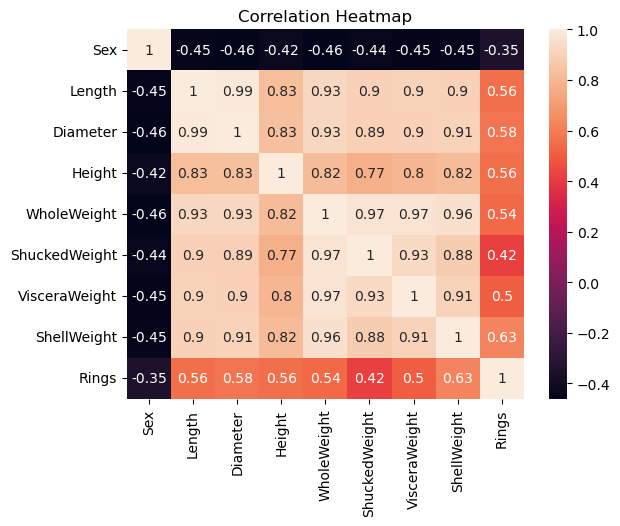

In [72]:
#Correaltion  Matrix 
corr = df.corr()
sns.heatmap(corr , annot = True)
plt.title("Correlation Heatmap")
plt.show()

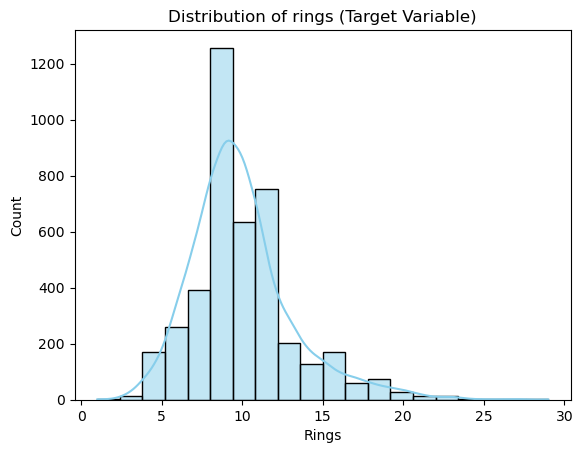

In [73]:
sns.histplot(df["Rings"],bins = 20 , kde = True, color = "skyblue")
plt.title("Distribution of rings (Target Variable)")
plt.show()

In [74]:
from sklearn.model_selection import train_test_split
X = df.drop("Rings",axis =1)
y = df["Rings"]
X_train,X_test,y_train,y_test= train_test_split(X,y)

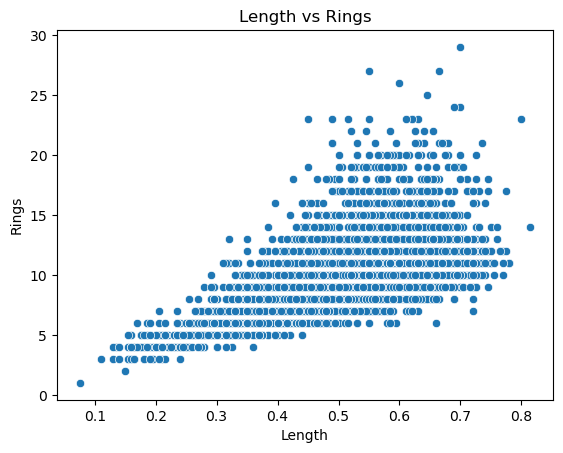

In [75]:
sns.scatterplot(x = 'Length',y="Rings",data= df)
plt.title("Length vs Rings")
plt.show()

In [76]:
#split the data
from sklearn.model_selection import train_test_split
X = df.drop("Rings",axis =1)
y = df["Rings"]
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)#random Sequence 42 tak ,test = 0.2 =20% and training = 80%

In [77]:
#pre-processing
X.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight',
       'VisceraWeight', 'ShellWeight'],
      dtype='object')

In [78]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4176 entries, 0 to 4175
Series name: Rings
Non-Null Count  Dtype
--------------  -----
4176 non-null   int64
dtypes: int64(1)
memory usage: 32.8 KB


In [79]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [80]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

results = {}
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f'{name}: MSE = {mse:.2f}, R2 = {r2:.2f}')

Linear Regression: MSE = 4.70, R2 = 0.58
Ridge Regression: MSE = 4.78, R2 = 0.57
Decision Tree: MSE = 9.30, R2 = 0.16
Random Forest: MSE = 4.78, R2 = 0.57


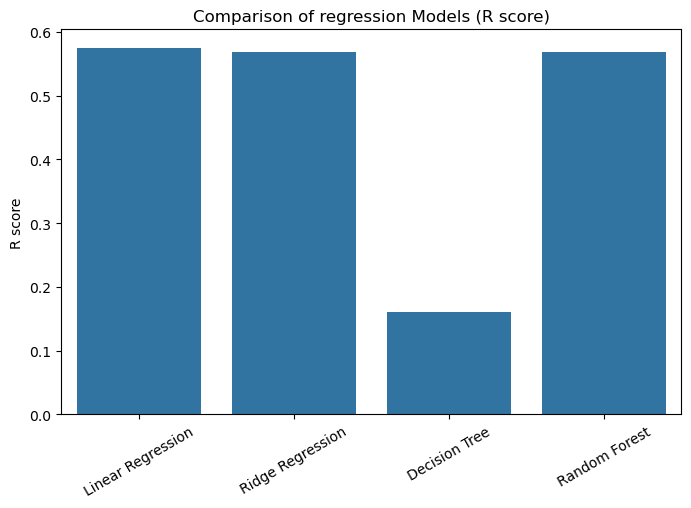

In [81]:
plt.figure(figsize=(8,5))
sns.barplot(x = list(results.keys()),y=list(results.values()))
plt.title("Comparison of regression Models (R score)")
plt.ylabel("R score")
plt.xticks(rotation=30)
plt.show()

In [82]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train,y_train)
y_pred = dtr.predict(X_test)
print("Decision Tree MSE :",mean_squared_error(y_test,y_pred))
print("Decision Tree R2:",r2_score(y_test,y_pred))

Decision Tree MSE : 8.405502392344498
Decision Tree R2: 0.2409242817522217


In [83]:
rdm = RandomForestRegressor()
rdm.fit(X_train,y_train)
y_pred = dtr.predict(X_test)
print("Decision Tree MSE :",mean_squared_error(y_test,y_pred))
print("Decision Tree R2:",r2_score(y_test,y_pred))

Decision Tree MSE : 8.405502392344498
Decision Tree R2: 0.2409242817522217


In [84]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = dtr.predict(features).reshape(1, -1)
    return pred[0]

In [85]:
Sex = 2
Length = 0.6
Diameter = 0.45
Height = 0.15
Whole_weight = 1.2
Shucked_weight = 0.6
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [14.]


In [86]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = rdm.predict(features).reshape(1, -1)
    return pred[0]

In [87]:
Sex = 2
Length = 0.6
Diameter = 0.45
Height = 0.15
Whole_weight = 1.2
Shucked_weight = 0.6
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [12.]


In [88]:
df.tail()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
4171,1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4172,0,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4173,0,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4174,1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4175,0,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [93]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = rdm.predict(features).reshape(1, -1)
    return pred[0]

In [94]:
Sex = 2
Length = 0.565
Diameter = 0.450
Height = 0.165
Whole_weight = 0.8870
Shucked_weight = 0.3700
Viscera_weight = 0.2390
Shell_weight = 0.2490

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [10.66]


In [95]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = dtr.predict(features).reshape(1, -1)
    return pred[0]

In [96]:
Sex = 2
Length = 0.565
Diameter = 0.450
Height = 0.165
Whole_weight = 0.8870
Shucked_weight = 0.3700
Viscera_weight = 0.2390
Shell_weight = 0.2490

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [11.]
